# 01: Data Acquisition

## Goal
Download weekly ICU bed data for California from the CDC's National Healthcare Safety Network (NHSN) and save an unedited copy to `data/raw/`. Every later notebook builds from this file.

## Why this dataset
Hospitals across the US are required to report bed capacity and occupancy to the CDC every week. That makes this one of the few public sources that tracks ICU demand consistently over several years. It also comes with real-world problems: periods when reporting was optional, changes in how many hospitals reported, and the COVID-19 surge distorting the early years. Handling those issues is part of the work.

## Scope
- **Geography:** California, state level
- **Time unit:** one row per week
- **Forecasting target (later notebooks):** number of occupied ICU beds

## What I want to learn in this notebook
- How far back the data goes
- How many variables are available
- Whether anything in the raw file needs attention before cleaning

In [7]:
import sys
from pathlib import Path
from datetime import date

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)

Python: 3.14.8
pandas: 3.0.6


In [8]:
raw_data_folder = Path("../data/raw")
raw_data_folder.mkdir(parents=True, exist_ok=True)

nhsn_dataset_url = (
    "https://data.cdc.gov/resource/ua7e-t2fy.csv"
    "?jurisdiction=CA"
    "&$limit=5000"
    "&$order=weekendingdate"
)

california_weekly_raw = pd.read_csv(nhsn_dataset_url)

download_date = date.today().isoformat()
raw_file_path = raw_data_folder / f"nhsn_hrd_california_weekly_{download_date}.csv"
california_weekly_raw.to_csv(raw_file_path, index=False)

print("Saved to:", raw_file_path)
print("Rows, columns:", california_weekly_raw.shape)
print("First week:", california_weekly_raw["weekendingdate"].min())
print("Last week:", california_weekly_raw["weekendingdate"].max())

Saved to: ../data/raw/nhsn_hrd_california_weekly_2026-10-06.csv
Rows, columns: (321, 322)
First week: 2020-08-08T00:00:00.000
Last week: 2026-09-26T00:00:00.000


In [9]:
week_ending_dates = pd.to_datetime(california_weekly_raw["weekendingdate"])

duplicate_week_count = week_ending_dates.duplicated().sum()
days_between_rows = week_ending_dates.diff().dropna().dt.days

print("Duplicate weeks:", duplicate_week_count)
print("Gaps between consecutive rows (days):")
print(days_between_rows.value_counts())

Duplicate weeks: 0
Gaps between consecutive rows (days):
weekendingdate
7    320
Name: count, dtype: int64


In [10]:
column_names = california_weekly_raw.columns.tolist()
print(len(column_names), "columns\n")
for column_name in column_names:
    print(column_name)

322 columns

weekendingdate
jurisdiction
numinptbeds
numinptbedsadult
numinptbedsped
numinptbedsocc
numinptbedsoccadult
numinptbedsoccped
numicubeds
numicubedsadult
numicubedsped
numicubedsocc
numicubedsoccadult
numicubedsoccped
numconfc19hosppatsadult
numconfc19hosppatsped
totalconfc19hosppats
numconffluhosppatsadult
numconffluhosppatsped
totalconffluhosppats
numconfrsvhosppatsadult
numconfrsvhosppatsped
totalconfrsvhosppats
numconfc19icupatsadult
numconfc19icupatsped
totalconfc19icupats
numconffluicupatsadult
numconffluicupatsped
totalconffluicupats
numconfrsvicupatsadult
numconfrsvicupatsped
totalconfrsvicupats
numconfc19newadmped0to4
numconfc19newadmped5to17
totalconfc19newadmped
numconfc19newadmadult18to49
numconfc19newadmadult50to64
numconfc19newadmadult65to74
numconfc19newadmadult75plus
totalconfc19newadmadult
numconfc19newadmunk
totalconfc19newadm
numconfflunewadmped0to4
numconfflunewadmped5to17
totalconfflunewadmped
numconfflunewadmadult18to49
numconfflunewadmadult50to64
numco

## Result
- 321 rows and 322 columns, one row per week, from August 8, 2020 to September 26, 2026.
- No week appears twice, and every row is exactly 7 days after the one before it.

## Interpretation
- The data has every week in the date range, with nothing skipped or repeated. This matters because a forecast learns from week-to-week changes. A missing week would make two weeks of change look like one.
- Each date marks the last day of the week the row covers. Dates are stored as text with a time of midnight attached, which adds nothing and will be removed.
- The 322 columns fall into three groups:
  - **Raw counts** reported by hospitals, such as ICU beds available, ICU beds in use, and patients with COVID-19, flu, or RSV.
  - **Calculated values** built from those counts, such as percentages, rates per 100,000 people, and weekly changes.
  - **Reporting coverage**, meaning how many hospitals sent in each number that week.
- The forecast needs the ICU counts and the reporting coverage. The calculated values can be rebuilt from the raw counts if needed.

## Limitations
Having a row for every week does not mean every hospital reported that week. Totals depend on how many hospitals sent in data. If fewer hospitals report, ICU numbers drop even when the same number of patients need care. This is a known risk from May through October 2024, when reporting was optional. The reporting coverage columns will be used to separate real changes in ICU demand from changes in who reported.

## Reporting Coverage Over Time

**Question:** Did the share of California hospitals reporting ICU data change over time, and do changes in ICU occupancy line up with changes in reporting?

**Why it matters:** If drops in ICU occupancy happen at the same time as drops in reporting, those drops may not reflect real changes in patient demand.

Missing values per column:
weekendingdate              0
numicubedsocc               0
numicubedsocchosprep        0
numicubedsoccperchosprep    0
week_ending                 0
dtype: int64


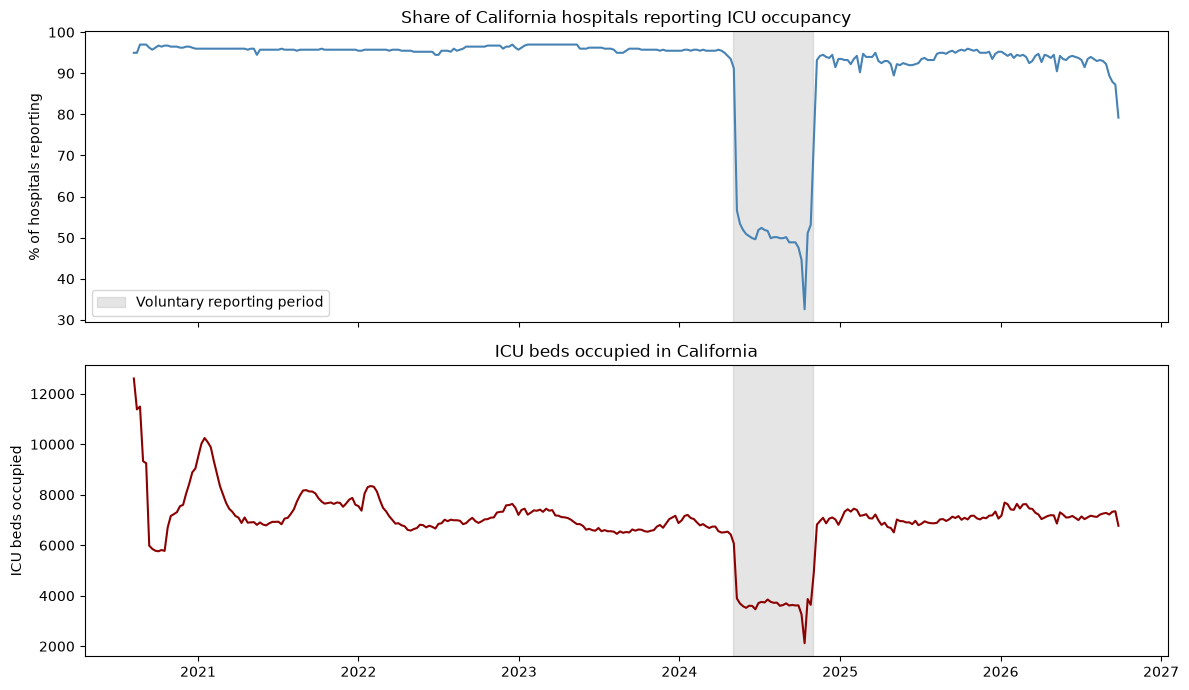

In [11]:
coverage_check = california_weekly_raw[
    ["weekendingdate", "numicubedsocc", "numicubedsocchosprep", "numicubedsoccperchosprep"]
].copy()

coverage_check["week_ending"] = pd.to_datetime(coverage_check["weekendingdate"]).dt.normalize()

print("Missing values per column:")
print(coverage_check.isna().sum())

voluntary_period_start = pd.Timestamp("2024-05-01")
voluntary_period_end = pd.Timestamp("2024-10-31")

figure, (coverage_axis, occupancy_axis) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True
)

coverage_axis.plot(
    coverage_check["week_ending"],
    coverage_check["numicubedsoccperchosprep"],
    color="steelblue",
)
coverage_axis.set_ylabel("% of hospitals reporting")
coverage_axis.set_title("Share of California hospitals reporting ICU occupancy")

occupancy_axis.plot(
    coverage_check["week_ending"],
    coverage_check["numicubedsocc"],
    color="darkred",
)
occupancy_axis.set_ylabel("ICU beds occupied")
occupancy_axis.set_title("ICU beds occupied in California")

for axis in (coverage_axis, occupancy_axis):
    axis.axvspan(
        voluntary_period_start,
        voluntary_period_end,
        color="gray",
        alpha=0.2,
        label="Voluntary reporting period",
    )

coverage_axis.legend(loc="lower left")
plt.tight_layout()
plt.show()

### Finding: the 2024 drop is a reporting artifact, not a real drop in demand

**Result**
- From May through October 2024, the share of hospitals reporting ICU data fell from about 95% to about 50%, with a low near 33%.
- Over the same weeks, ICU beds occupied fell from about 6,500 to about 3,600.
- Both returned to normal levels in November 2024, when reporting became required again.

**Interpretation**
Reporting fell by about half, and ICU occupancy fell by about half, starting and ending on the same dates. This points to a measurement artifact: the totals dropped because fewer hospitals sent in data, not because fewer patients needed intensive care. A model trained on these weeks as they are would learn a drop in demand that never happened.

**Limitation**
The chart shows the drops line up, but it cannot show how many patients were actually in ICUs during those weeks. That number is unknown for this period.

### Early 2020: what caused the drop from August to October?

ICU occupancy fell from about 12,600 to under 6,000 in the first two months of data, while reporting stayed near 95%. Reporting cannot explain this drop. The two remaining explanations are a real decline as the summer 2020 COVID-19 wave faded, or a change in how ICU beds were counted. This check compares total occupancy, ICU capacity, and COVID-19 ICU patients over those weeks.

In [12]:
early_weeks_check = california_weekly_raw[
    [
        "weekendingdate",
        "numicubeds",
        "numicubedsocc",
        "totalconfc19icupats",
        "numicubedsoccperchosprep",
    ]
].head(14)

early_weeks_check["weekendingdate"] = pd.to_datetime(
    early_weeks_check["weekendingdate"]
).dt.date

print(early_weeks_check.to_string(index=False))

weekendingdate  numicubeds  numicubedsocc  totalconfc19icupats  numicubedsoccperchosprep
    2020-08-08    18281.57       12607.14              1827.80                     94.99
    2020-08-15    16628.50       11382.23              1687.75                     94.99
    2020-08-22    16644.84       11493.84              1574.31                     96.99
    2020-08-29    13674.43        9330.76              1368.66                     96.99
    2020-09-05    13751.01        9250.23              1166.32                     96.99
    2020-09-12     8977.98        5983.96              1064.62                     96.24
    2020-09-19     8958.73        5855.95               886.57                     95.74
    2020-09-26     8945.02        5783.39               793.47                     96.24
    2020-10-03     8927.45        5762.45               701.02                     96.74
    2020-10-10     8980.79        5812.71               663.04                     96.49
    2020-10-17     90

### Finding: early 2020 changes reflect counting changes, not real changes in demand

**Result**
- From August 8 to September 12, 2020, ICU occupancy fell by about 6,600 beds, while COVID-19 ICU patients fell by only about 760.
- In the week ending September 12, ICU capacity and ICU occupancy both fell by about 35%, while COVID-19 ICU patients fell by about 9%.
- In late October 2020, capacity and occupancy both rose by about 20% while COVID-19 ICU patients barely changed.
- Throughout these jumps, the share of ICU beds in use stayed between about 64% and 69%.

**Interpretation**
The fading COVID-19 wave explains only about 12% of the decline. When patients leave, beds empty out but the beds themselves remain. Here, capacity and occupancy moved together by the same percentage in the same week, which is the pattern expected when the definition of what counts as an ICU bed changes. The occupancy share stayed steady through these changes, which suggests the percentage may be a more stable measure than the raw counts.

**Limitation**
The data shows a definition change happened, but not what the change was.

### The most recent weeks: is the latest data complete?

Reporting falls from about 93% to about 79% in the final weeks of the file. The most likely explanation is late reporting: some hospitals submit after the deadline, and the CDC fills in those numbers later. This check looks at the last eight weeks in detail.

In [13]:
recent_weeks_check = california_weekly_raw[
    ["weekendingdate", "numicubeds", "numicubedsocc", "numicubedsoccperchosprep"]
].tail(8).copy()

recent_weeks_check["weekendingdate"] = pd.to_datetime(
    recent_weeks_check["weekendingdate"]
).dt.date

recent_weeks_check["occupancy_share_pct"] = (
    recent_weeks_check["numicubedsocc"] / recent_weeks_check["numicubeds"] * 100
).round(1)

print(recent_weeks_check.to_string(index=False))

weekendingdate  numicubeds  numicubedsocc  numicubedsoccperchosprep  occupancy_share_pct
    2026-08-08     10476.0         7123.0                     92.98                 68.0
    2026-08-15     10604.0         7215.0                     93.23                 68.0
    2026-08-22     10631.0         7257.0                     92.98                 68.3
    2026-08-29     10598.0         7281.0                     92.23                 68.7
    2026-09-05     10394.0         7218.0                     89.47                 69.4
    2026-09-12     10371.0         7327.0                     87.97                 70.6
    2026-09-19     10491.0         7347.0                     87.22                 70.0
    2026-09-26      9904.0         6772.0                     79.20                 68.4


### Finding: the most recent week is likely undercounted

**Result**
- Reporting fell from about 93% in late August to about 88% by mid-September, then to 79% in the final week (ending September 26, 2026).
- ICU occupancy held steady through mid-September, then fell from 7,347 to 6,772 in the final week, a drop of about 8%.
- ICU capacity fell by about 6% in the same week.
- The share of ICU beds in use stayed between 68% and 71% across all eight weeks.

**Interpretation**
The moderate dip in reporting during September did not visibly lower ICU counts. The final week did: capacity and occupancy fell together while the share of beds in use held steady. This matches what happens when some hospitals are missing from the total, removing both their beds and their patients. The most likely cause is late reporting, where hospitals that have not yet submitted are filled in later. This matters for forecasting because a forecast starts from the latest week, and an undercounted starting point would pull every forecast too low.

**Limitation**
One download cannot confirm late reporting. Downloading again in a few weeks and checking whether this week fills in would confirm it.

## Data Quality Summary

| Period | What happened | Cause | Affects |
|---|---|---|---|
| Aug to Oct 2020 | ICU counts dropped, then jumped | Change in how ICU beds were counted | Raw counts. Occupancy share held steady. |
| May to Oct 2024 | ICU counts fell by about half | Reporting was optional, and about half of hospitals stopped reporting | Raw counts |
| Final week of the file | Reporting and counts dip | Likely late reporting, not yet confirmed | Raw counts and the forecast starting point. Occupancy share held steady. |

All three issues change the raw ICU counts without reflecting real changes in patient demand. How to handle each one is decided in the cleaning notebook.